<a href="https://colab.research.google.com/github/mnsbharadwaj/AI-NLP/blob/master/Transformer_components.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **POSTIONAL ENCODING**

In transformers, the model sees the input as a set of tokens (words or subwords).

However, it does not know the order of tokens (i.e., ["I", "am", "happy"] vs ["happy", "am", "I"]).

Positional Encoding adds unique information about token positions to the embeddings, allowing the model to learn sequence order.

For each position pos and dimension 𝑖:

 PE pos, 2i = sin(pos/(10000^((2i)/embedding_size)))

 PE pos,2i+1 = cos(pos/(10000^((2i)/embedding_size)))



You usually see graphs showing sinusoidal waves across dimensions.

Explaining PE for a single token "SAT" in a sentence "[PAD]", "The", "cat", "sat", "on", "the", "mat", ".", "[EOS]"

Each line represents how the positional encoding values change across the 64 dimensions for a specific token.

It clearly shows how token position affects the encoding.
 Both sine and cosine are used for every token — but in alternating dimensions of its positional encoding vector.

 For each postion say 3 and model dimension 6 the PE vector looks like this:
 | Dimension `i` | Formula Used   | Value           |

   0              $\sin\left(\frac{pos}{10000^{0/d}}\right)$  $\sin(3 / 1)



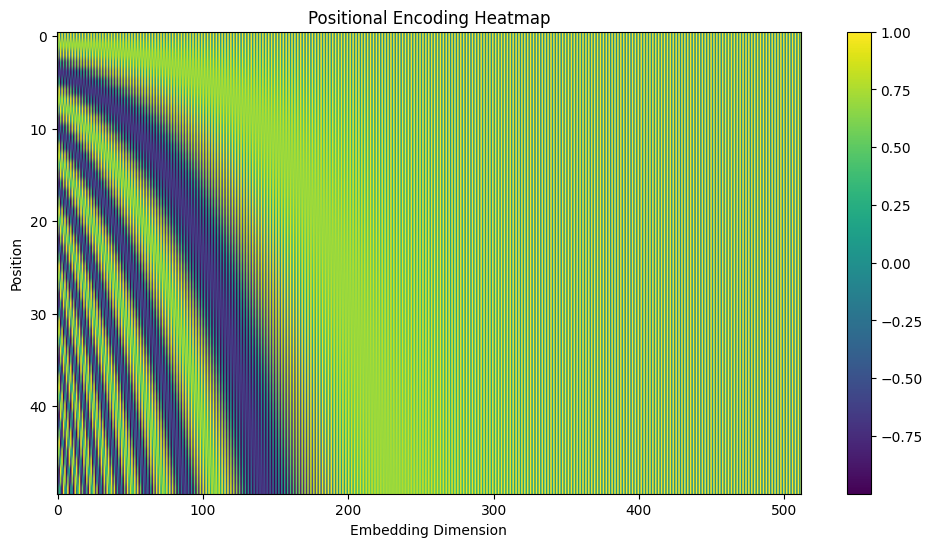

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def positional_encoding(position, d_model):
    angle_rates = 1 / np.power(10000, (2 * (np.arange(d_model)//2)) / np.float32(d_model))
    angle_rads = position * angle_rates[np.newaxis, :]  # shape: (position, d_model)

    # apply sin to even indices; cos to odd indices
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
    return angle_rads

pos_encoding = positional_encoding(np.arange(50)[:, np.newaxis], 512)

plt.figure(figsize=(12, 6))
plt.imshow(pos_encoding, aspect='auto', cmap='viridis')
plt.colorbar()
plt.xlabel('Embedding Dimension')
plt.ylabel('Position')
plt.title('Positional Encoding Heatmap')
plt.show()


## The positional encoding heatmap graph (50 positions × 512 dimensions) gives visual insight into how transformers encode token positions using sine and cosine waves.

# Visualize Postional encoding of a single token in a  line graph

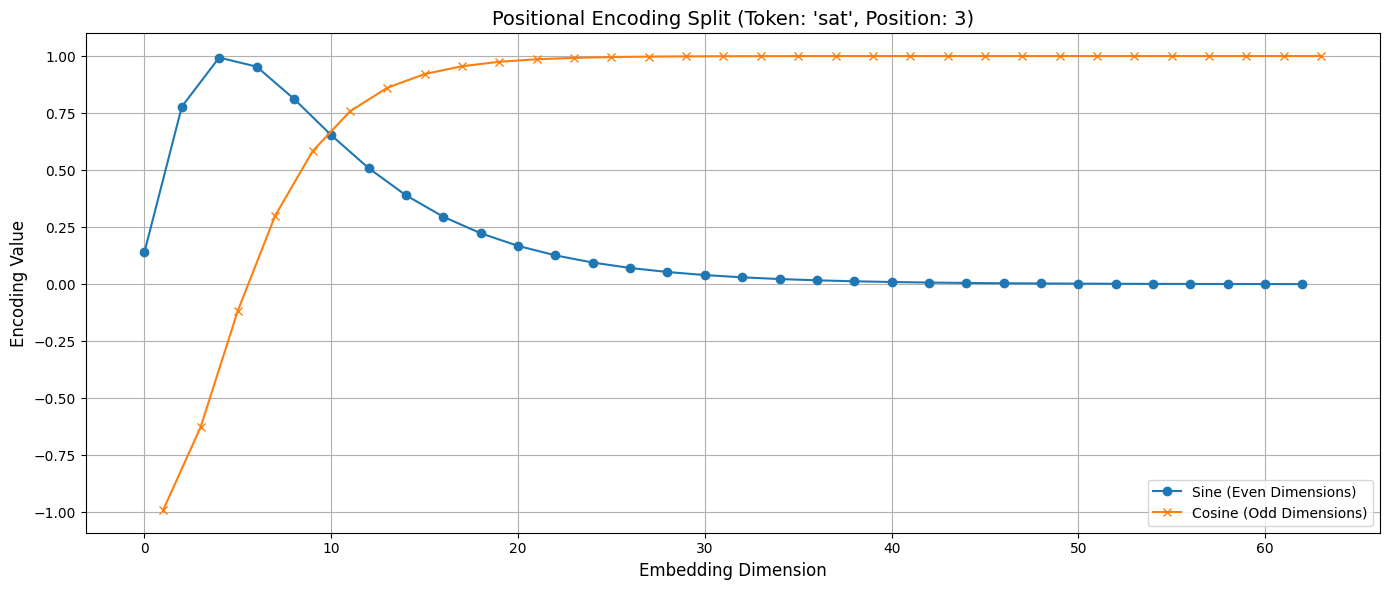

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define the positional encoding function
def positional_encoding(position, d_model):
    angle_rates = 1 / np.power(10000, (2 * (np.arange(d_model)//2)) / np.float32(d_model))
    angle_rads = position * angle_rates[np.newaxis, :]
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
    return angle_rads

# Token setup
tokens = ["[PAD]", "The", "cat", "sat", "on", "the", "mat", ".", "[EOS]"]
pos_index = 3  # e.g., "sat"
d_model = 64

# Compute encoding
positions = np.arange(len(tokens))[:, np.newaxis]
pos_encoding = positional_encoding(positions, d_model)
token_encoding = pos_encoding[pos_index]
dimensions = np.arange(d_model)

# Plot sine and cosine parts
plt.figure(figsize=(14, 6))
plt.plot(dimensions[::2], token_encoding[::2], label="Sine (Even Dimensions)", marker='o')
plt.plot(dimensions[1::2], token_encoding[1::2], label="Cosine (Odd Dimensions)", marker='x')
plt.title(f"Positional Encoding Split (Token: '{tokens[pos_index]}', Position: {pos_index})", fontsize=14)
plt.xlabel("Embedding Dimension", fontsize=12)
plt.ylabel("Encoding Value", fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Visualize Postional encoding of a 2 tokens in a line graph

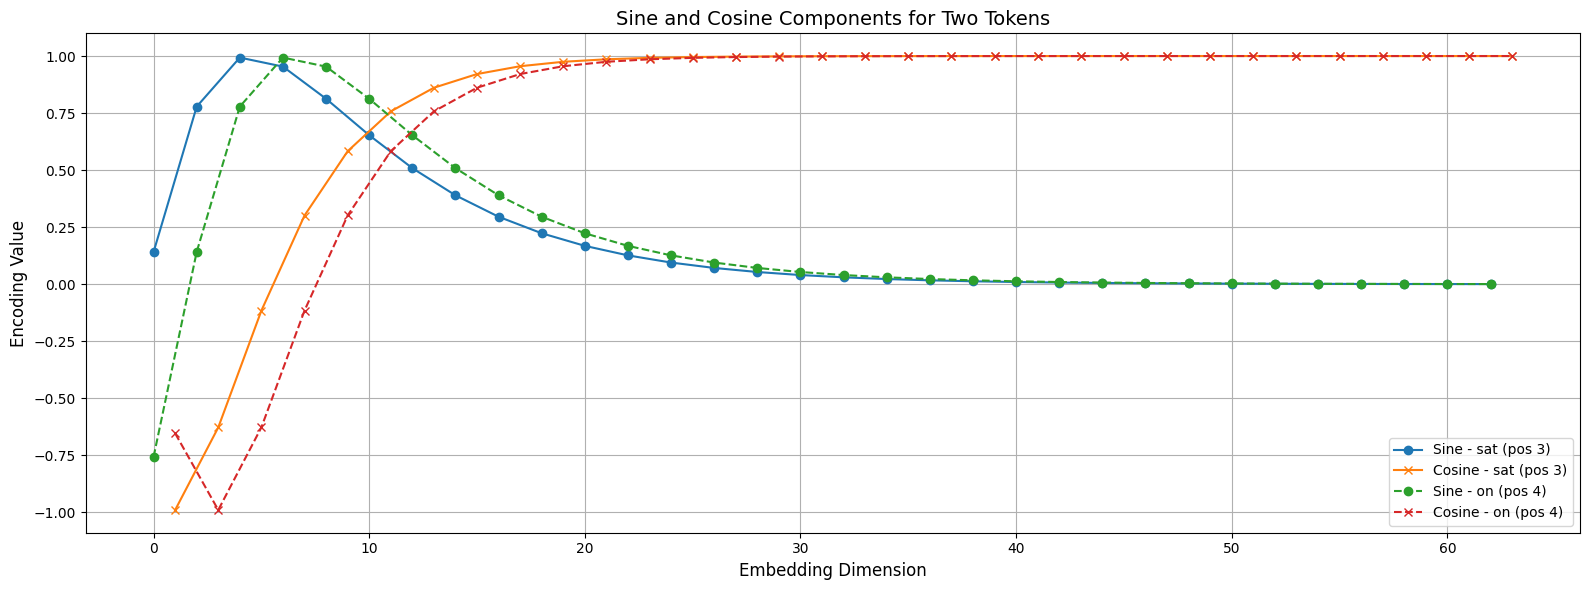

In [2]:
# Choose two positions
pos1 = 3  # "sat"
pos2 = 4  # "on"
encoding1 = pos_encoding[pos1]
encoding2 = pos_encoding[pos2]

# Plot sine/cosine comparison for two tokens
plt.figure(figsize=(16, 6))
plt.plot(dimensions[::2], encoding1[::2], label=f"Sine - {tokens[pos1]} (pos {pos1})", marker='o')
plt.plot(dimensions[1::2], encoding1[1::2], label=f"Cosine - {tokens[pos1]} (pos {pos1})", marker='x')
plt.plot(dimensions[::2], encoding2[::2], label=f"Sine - {tokens[pos2]} (pos {pos2})", linestyle='--', marker='o')
plt.plot(dimensions[1::2], encoding2[1::2], label=f"Cosine - {tokens[pos2]} (pos {pos2})", linestyle='--', marker='x')

plt.title("Sine and Cosine Components for Two Tokens", fontsize=14)
plt.xlabel("Embedding Dimension", fontsize=12)
plt.ylabel("Encoding Value", fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Visualize Postional encoding of all tokens in a line graph

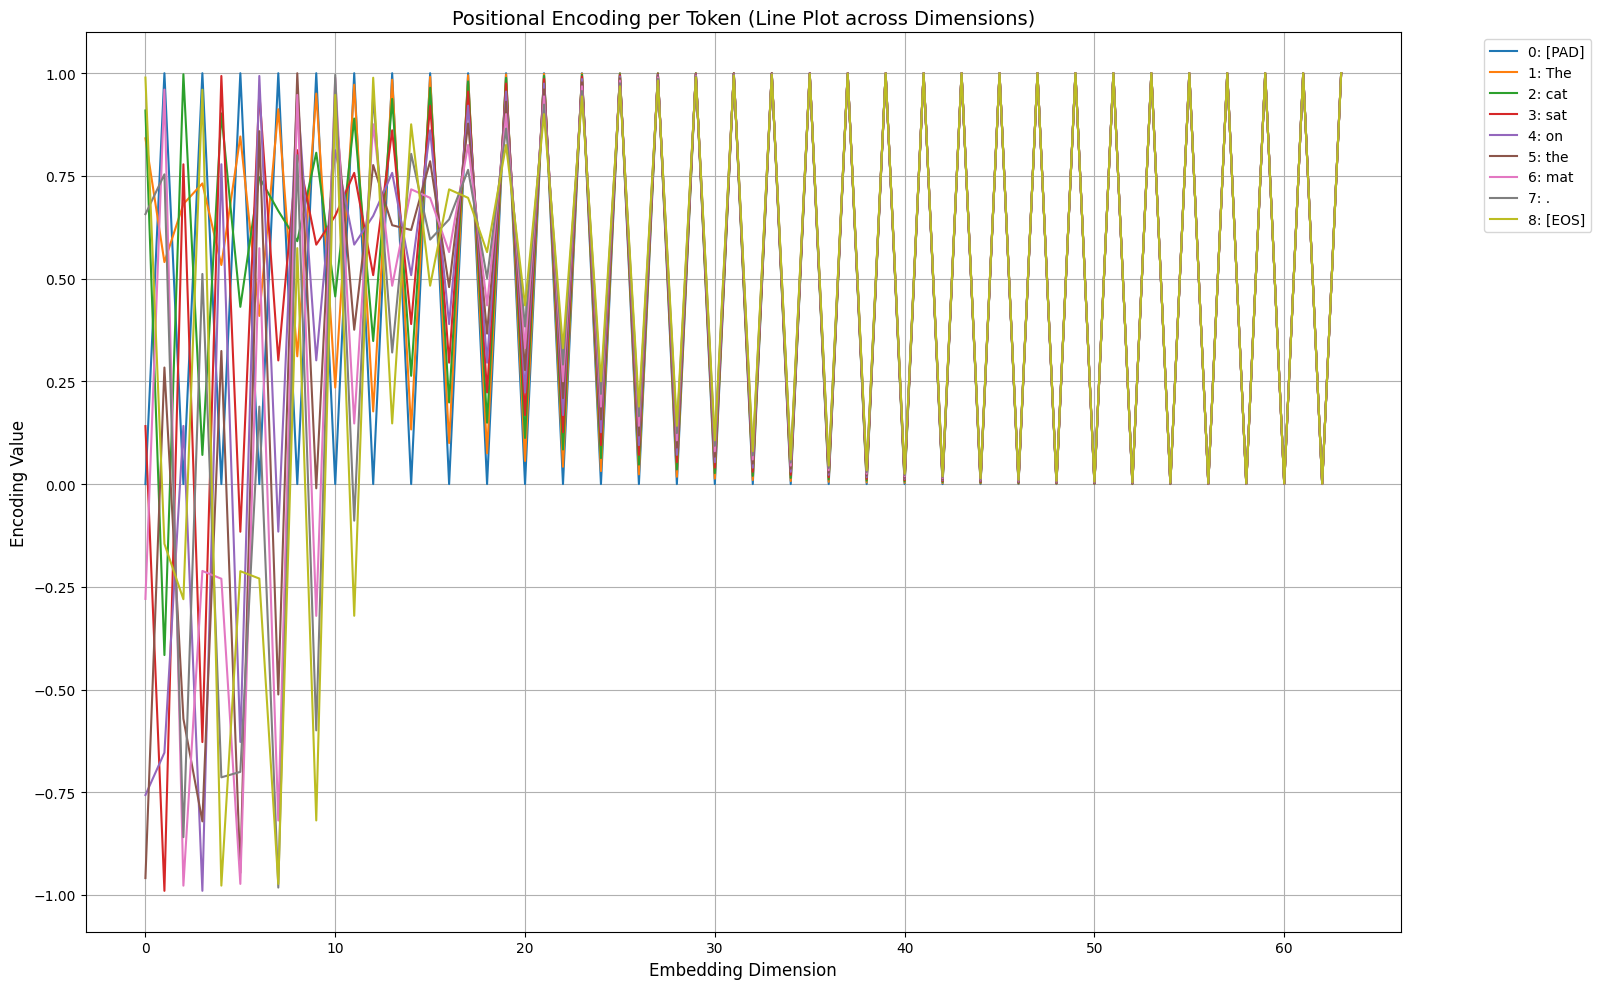

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Define the positional encoding function
def positional_encoding(position, d_model):
    angle_rates = 1 / np.power(10000, (2 * (np.arange(d_model)//2)) / np.float32(d_model))
    angle_rads = position * angle_rates[np.newaxis, :]  # (position, d_model)
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])   # sin for even indices
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])   # cos for odd indices
    return angle_rads

# Define example tokens and parameters
tokens = ["[PAD]", "The", "cat", "sat", "on", "the", "mat", ".", "[EOS]"]
max_len = len(tokens)
d_model = 64  # Smaller size for visualization

# Generate the positional encodings
positions = np.arange(max_len)[:, np.newaxis]
pos_encoding = positional_encoding(positions, d_model)

# Plot line graph showing positional encoding for each token
plt.figure(figsize=(16, 10))
for i, token in enumerate(tokens):
    plt.plot(pos_encoding[i], label=f"{i}: {token}")

plt.xlabel("Embedding Dimension", fontsize=12)
plt.ylabel("Encoding Value", fontsize=12)
plt.title("Positional Encoding per Token (Line Plot across Dimensions)", fontsize=14)
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1.0))
plt.grid(True)
plt.tight_layout()
plt.show()


## SELF ATTENTION

Self Attention:

Explanation of Self-Attention

Self-attention is a mechanism that allows a neural network to weigh the importance of different words in an input sequence to better understand the context of each word. Unlike traditional recurrent neural networks (RNNs) which process words sequentially, self-attention looks at the entire sequence simultaneously and computes a weighted sum of all input words for each output word. This weighted sum represents the contextually enriched representation of a word.

Here's how it works conceptually:

Queries, Keys, and Values: For each word in the input sequence, three vectors are created: a Query (Q), a Key (K), and a Value (V). These are typically derived from the original word embedding through linear transformations. Think of the Query as asking "what should I pay attention to?", the Key as a descriptor of what is available to be attended to, and the Value as the actual information to be aggregated.

Calculating Attention Scores: For each word's Query vector, it's compared with the Key vector of every other word in the sequence (including itself). This comparison is usually done using a dot product. The result is a score representing the similarity or relevance between the Query word and each Key word. A higher score means the Query word should pay more attention to that Key word.

Scaling and Softmax: The attention scores are typically scaled down (to prevent exploding gradients) and then passed through a softmax function. The softmax converts the scores into a probability distribution, where the probabilities sum up to 1. These probabilities represent the attention weights – how much attention the current word should pay to each other word in the sequence.

Weighted Sum of Values: The attention weights are then used to compute a weighted sum of the Value vectors of all words in the sequence. This weighted sum is the output representation for the current word, effectively incorporating information from the most relevant words in the sequence.

This process is repeated for every word in the input sequence, producing a new sequence of contextually richer representations.

Example:

Consider the sentence: "The animal didn't cross the street because it was too wide."

When processing the word "it", self-attention allows the network to understand that "it" refers to "the street". This is done by calculating attention scores between "it" (as the Query) and all other words (as Keys). The score between "it" and "the street" would be high, leading to a high attention weight for "the street" when computing the weighted sum of values for "it".

Now consider the sentence: "The animal didn't cross the street because it was too tired."

In this case, self-attention would likely assign a high attention weight to "the animal" when processing "it", correctly identifying that "it" refers to "the animal".

Diagram Description:

A typical diagram illustrating self-attention would show the following steps:

Input Embeddings: A sequence of word embeddings is shown as input.
Linear Transformations: Arrows would show each embedding being transformed into Query, Key, and Value vectors.
Dot Product: A matrix multiplication operation is depicted where the Query matrix is multiplied by the transposed Key matrix to obtain the attention scores.
Scaling and Softmax: The attention scores are shown being scaled and then passed through a softmax function to get attention weights.
Weighted Sum: The attention weights are shown multiplying the Value matrix, and the results are summed to produce the output context vectors.
The diagram would visually represent how each output vector is a weighted combination of the input Value vectors, with the weights determined by the attention scores. It would highlight the pairwise interactions between words in the sequence.



# Step-by-Step Breakdown of Self-Attention. Ex Sentence - "Lion looked at Zebra. It roared."

# 1. Tokenization
The sentence becomes tokens:["Lion", "looked", "at", "Zebra", ".", "It", "roared", "."].

Each of these will be represented by an embedding vector, say of dimension 4 or 8 (in real models, it's 512 or 768).

# 2. Create Q, K, V Vectors
Each token’s embedding is linearly projected into:

Q (Query vector): what this token is looking for

K (Key vector): what this token offers

V (Value vector): what actual information it carries

For example:

"roared" will get a Q vector

Every token (including "lion") will have a K and V.

# 3. Compute Attention Scores
Each token (say "roared") computes attention with all tokens:

score = 𝑄roared⋅𝐾token

Let’s say:

The dot product with "lion" is high (e.g., 3.2)

With "zebra", it's low (e.g., 0.4)

This shows "roared" is more interested in "lion", possibly because "lion" is the subject, and "roared" is a verb needing a subject.

# 4. Softmax Over Scores

**Token                    Raw Score                 Softmax**

Lion                        3.2                     0.78

looked                     1.5                      0.10

at                         0.7                      0.04

zebra                      0.4                      0.03

it                         1.2                       0.05


So "roared" gives 78% of its attention to "lion".

# 5.Weighted Sum of Value Vectors

Multiply each V vector by its attention weight and sum them up.

This gives a new vector for "roared" that is:

Mostly influenced by "lion"

Slightly by "looked", "It", etc.

# 6. Result: Context-Aware Embedding
Now the output for "roared" reflects:

That it’s likely "lion" who roared (not zebra!)

So when the model generates or classifies, it understands this dependency